In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_curve, auc, mean_absolute_error,root_mean_squared_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
import warnings
from sklearn import datasets

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

1.1. Otwarcie  pliku  z  danymi.

In [73]:
df = pd.read_csv('StudentPerformanceFactors.csv')

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


1.2. Sprawdzenie kompletności danych.

In [74]:
print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


1.3. Sprawdzenie podstawowych statystyk.

In [75]:
print(df.describe())

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235659  
std             1.230570           1.031231     3.890456  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             1.000000           3.00000

In [76]:
print(df.dtypes)

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


1.4. Wizualizacja: Heatmapa ze względu na liczbę brakujących danych. 

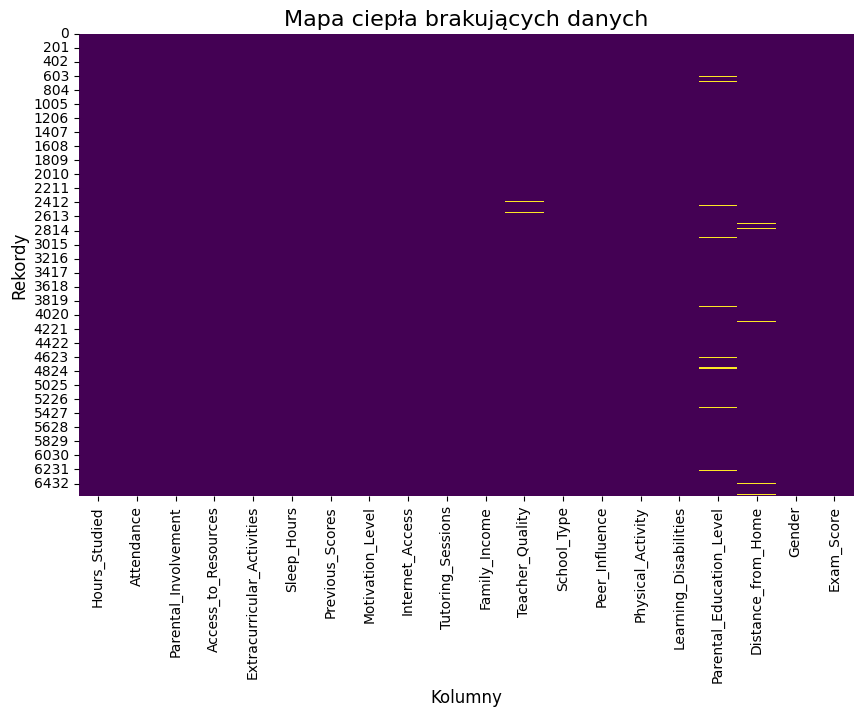

In [77]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa ciepła brakujących danych', fontsize=16)
plt.xlabel('Kolumny', fontsize=12)
plt.ylabel('Rekordy', fontsize=12)

plt.show()

zrobic jakies wykresy potem

2. Przekształcenie danych.

2.1. Usuniecie niepotrzebnych kolumn.

In [78]:
df.drop(['Physical_Activity', 'Peer_Influence', 'Parental_Education_Level', 'Family_Income'], axis=1, inplace=True)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Teacher_Quality,School_Type,Learning_Disabilities,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Medium,Public,No,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Public,No,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Public,No,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Public,No,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,High,Public,No,Near,Female,70


2.2. Mapowanie kolumn: Gender, Distance_from_Home, Access_to_Resources, Parental_Involvement, Motivation_Level, Teacher_Quality. 

Zamiana na wartosci liczbowe oraz uzupelnienie brakujących danych medianą gdzie trzeba.

In [79]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [80]:
df['Distance_from_Home'] = df['Distance_from_Home'].map({'Near': 0, 'Moderate': 1, 'Far': 2})

median_distance = df['Distance_from_Home'].median()
print(median_distance)

# Wypełnienie brakujących wartości medianą
df['Distance_from_Home'].fillna(median_distance, inplace=True)

# Sprawdzenie wyników
print(df['Distance_from_Home'].isnull().sum())  # Powinno zwrócić 0
print(df['Distance_from_Home'].head(10))  # Podgląd przetworzonych danych

0.0
0
0    0.0
1    1.0
2    0.0
3    1.0
4    0.0
5    0.0
6    1.0
7    2.0
8    0.0
9    1.0
Name: Distance_from_Home, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_19936\1442269923.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Distance_from_Home'].fillna(median_distance, inplace=True)


In [81]:
df['Access_to_Resources'] = df['Access_to_Resources'].map({'Low': 0, 'Medium': 1, 'High': 2})

print(df['Access_to_Resources'].head(10))  # Podgląd przetworzonych dany

0    2
1    1
2    1
3    1
4    1
5    1
6    0
7    2
8    2
9    1
Name: Access_to_Resources, dtype: int64


In [82]:
df['Parental_Involvement'] = df['Parental_Involvement'].map({'Low': 0, 'Medium': 1, 'High': 2})

print(df['Parental_Involvement'].head(10))  # Podgląd przetworzonych dany

0    0
1    0
2    1
3    0
4    1
5    1
6    1
7    0
8    1
9    1
Name: Parental_Involvement, dtype: int64


In [83]:
df['Motivation_Level'] = df['Motivation_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

print(df['Motivation_Level'].head(10))  # Podgląd przetworzonych dany

0    0
1    0
2    1
3    1
4    1
5    1
6    0
7    1
8    2
9    1
Name: Motivation_Level, dtype: int64


In [84]:
df['Teacher_Quality'] = df['Teacher_Quality'].map({'Low': 0, 'Medium': 1, 'High': 2})

median_distance = df['Teacher_Quality'].median()
print(median_distance)

# Wypełnienie brakujących wartości medianą
df['Teacher_Quality'].fillna(median_distance, inplace=True)

# Sprawdzenie wyników
print(df['Teacher_Quality'].isnull().sum())  # Powinno zwrócić 0
print(df['Teacher_Quality'].head(10))  # Podgląd przetworzonych dany

1.0
0
0    1.0
1    1.0
2    1.0
3    1.0
4    2.0
5    1.0
6    1.0
7    2.0
8    0.0
9    2.0
Name: Teacher_Quality, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_19936\1809797257.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Teacher_Quality'].fillna(median_distance, inplace=True)


2.3. Dummying kolumn ['Learning_Disabilities','Internet_Access', 'School_Type', 'Extracurricular_Activities'].

In [85]:
df = pd.get_dummies(df, columns=['Learning_Disabilities','Internet_Access', 'School_Type', 'Extracurricular_Activities'], drop_first=True)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Teacher_Quality,Distance_from_Home,Gender,Exam_Score,Learning_Disabilities_Yes,Internet_Access_Yes,School_Type_Public,Extracurricular_Activities_Yes
0,23,84,0,2,7,73,0,0,1.0,0.0,0,67,False,True,True,False
1,19,64,0,1,8,59,0,2,1.0,1.0,1,61,False,True,True,False
2,24,98,1,1,7,91,1,2,1.0,0.0,0,74,False,True,True,True
3,29,89,0,1,8,98,1,1,1.0,1.0,0,71,False,True,True,True
4,19,92,1,1,6,65,1,3,2.0,0.0,1,70,False,True,True,True


2.4. Wykresy

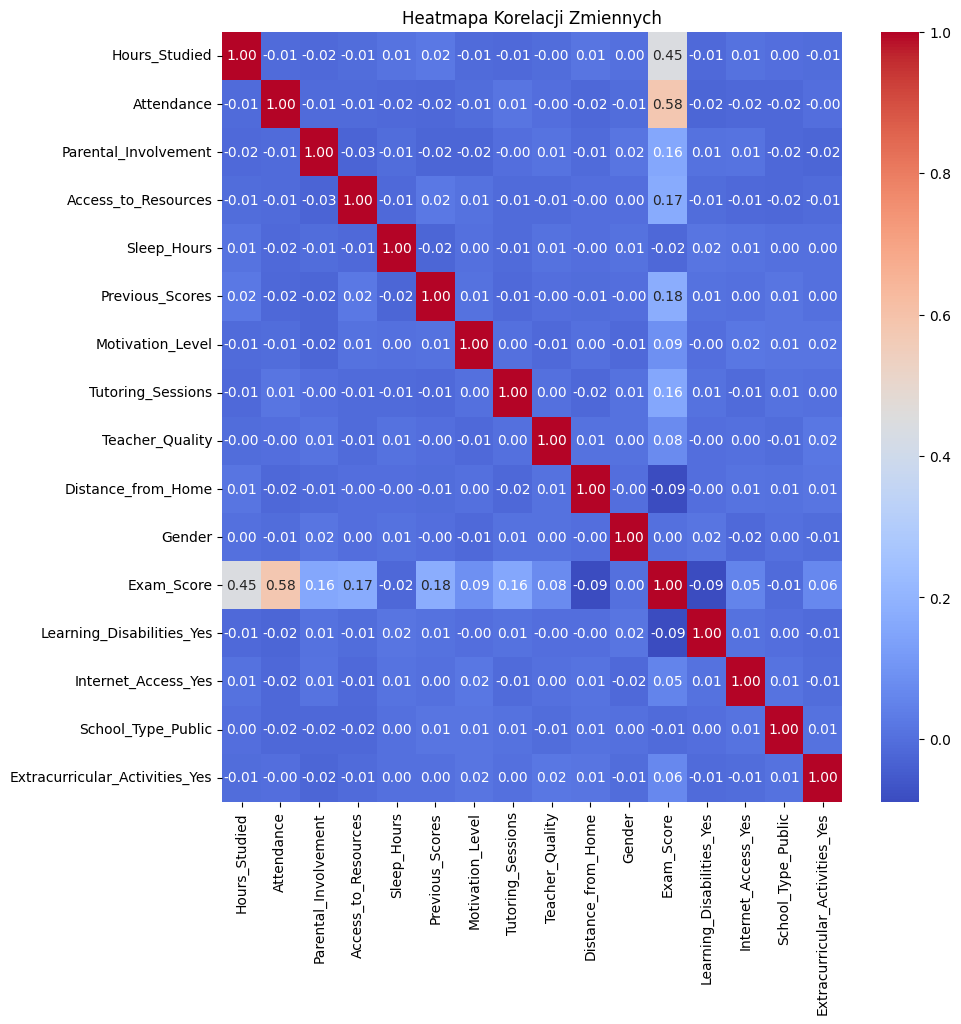

In [86]:
plt.figure(figsize=(10, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmapa Korelacji Zmiennych')
plt.show()

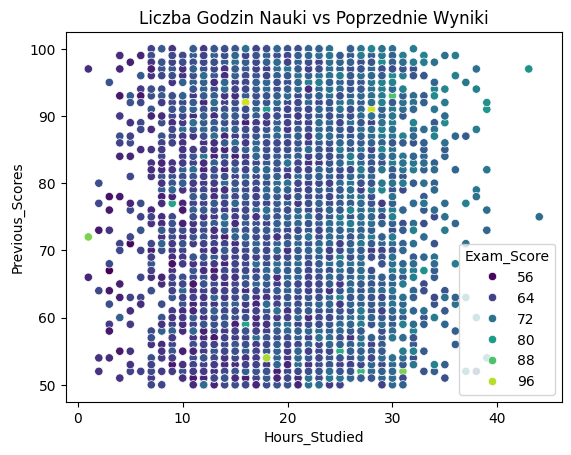

In [87]:
sns.scatterplot(data=df, x='Hours_Studied', y='Previous_Scores', hue='Exam_Score', palette='viridis')
plt.title('Liczba Godzin Nauki vs Poprzednie Wyniki')
plt.show()

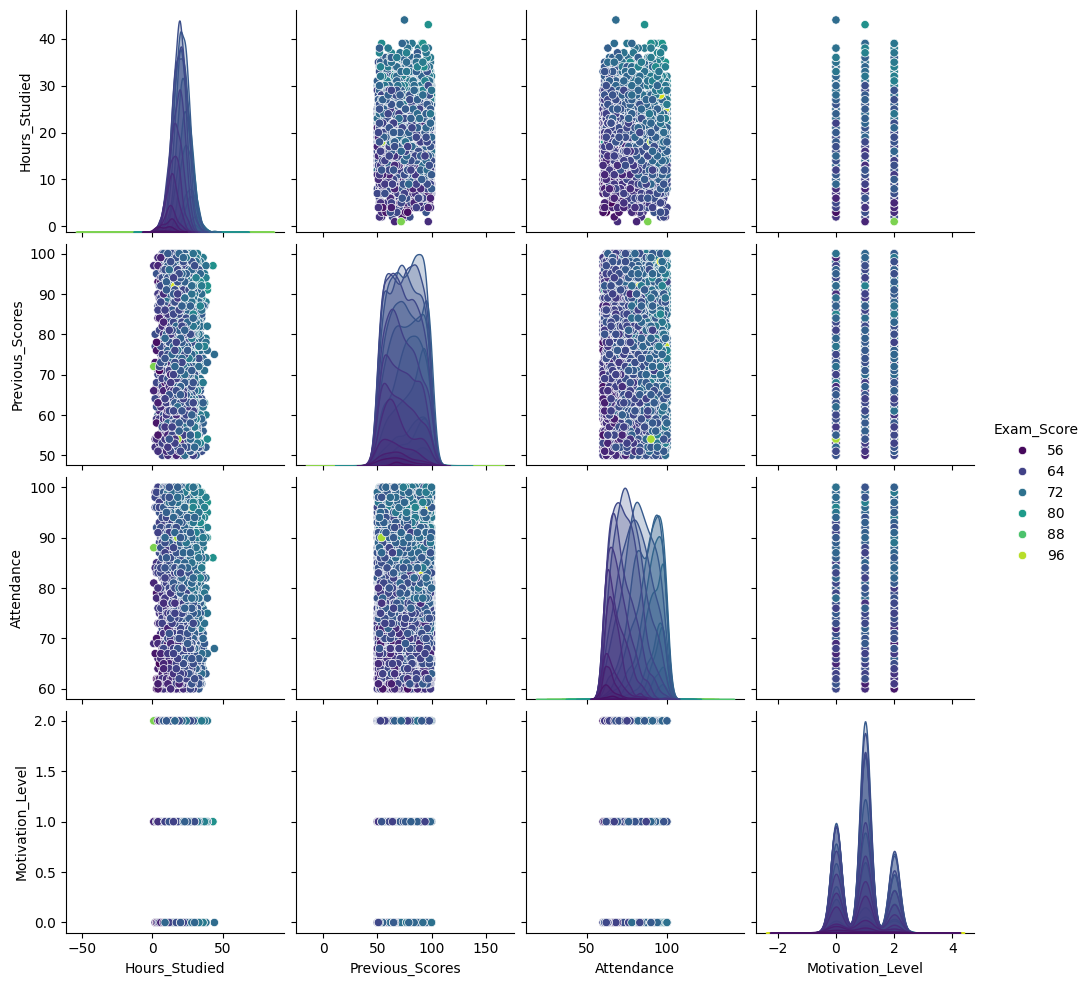

In [88]:
selected_features = df[['Hours_Studied', 'Previous_Scores', 'Attendance', 'Motivation_Level', 'Exam_Score']]
sns.pairplot(selected_features, hue='Exam_Score', palette='viridis')
plt.show()

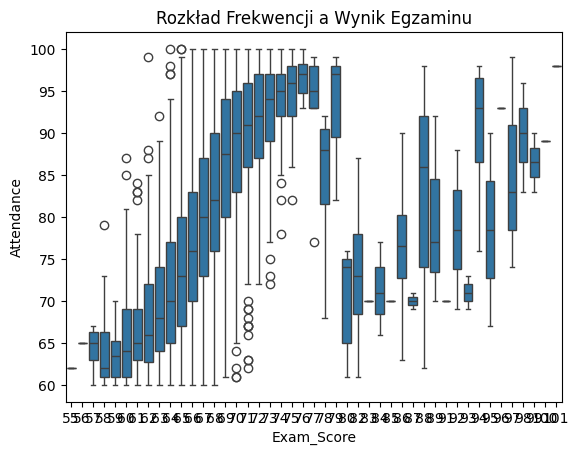

In [89]:
sns.boxplot(data=df, x='Exam_Score', y='Attendance')
plt.title('Rozkład Frekwencji a Wynik Egzaminu')
plt.show()

In [90]:
bins = [0, 50, 60, 70, 80 , 90, 101]
labels = [1, 2, 3, 4, 5, 6]

df_categories = df.copy()

# Użycie pd.cut do przekształcenia wyników na przedziały w df1
df_categories['score_category'] = pd.cut(df_categories['Exam_Score'], bins=bins, labels=labels, right=True)

df_categories.drop(['Exam_Score'], axis=1, inplace=True)

df_categories.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Teacher_Quality,Distance_from_Home,Gender,Learning_Disabilities_Yes,Internet_Access_Yes,School_Type_Public,Extracurricular_Activities_Yes,score_category
0,23,84,0,2,7,73,0,0,1.0,0.0,0,False,True,True,False,3
1,19,64,0,1,8,59,0,2,1.0,1.0,1,False,True,True,False,3
2,24,98,1,1,7,91,1,2,1.0,0.0,0,False,True,True,True,4
3,29,89,0,1,8,98,1,1,1.0,1.0,0,False,True,True,True,4
4,19,92,1,1,6,65,1,3,2.0,0.0,1,False,True,True,True,3


In [91]:
# Przekształcenie kolumny 'Exam_Score' i previous score na 1 dla wartosci wiekszej lub rownej 70%
df['Exam_Score'] = (df['Exam_Score'] > 69).astype(int)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Teacher_Quality,Distance_from_Home,Gender,Exam_Score,Learning_Disabilities_Yes,Internet_Access_Yes,School_Type_Public,Extracurricular_Activities_Yes
0,23,84,0,2,7,73,0,0,1.0,0.0,0,0,False,True,True,False
1,19,64,0,1,8,59,0,2,1.0,1.0,1,0,False,True,True,False
2,24,98,1,1,7,91,1,2,1.0,0.0,0,1,False,True,True,True
3,29,89,0,1,8,98,1,1,1.0,1.0,0,1,False,True,True,True
4,19,92,1,1,6,65,1,3,2.0,0.0,1,1,False,True,True,True


In [92]:
# Zresetowanie list do zapisu wyników poszczególnych modeli
models = ['Linear Regression', 'Logistic Regression', 'KNN', 'SVM']
accuracies = []
precisions = []
recalls = []
f1_scores = []

Linear regression dla kategorii.

In [93]:
y = df_categories['score_category']
X = df_categories.drop(['score_category'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

Mean Absolute Error: 0.2502340492975756
Mean Squared Error: 0.12003443390037015
Root Mean Squared Error: 0.34645985900298776
R² Score: 0.4009020749063896


Linear regression dla wynikow 0 i 1 (wynik egzaminu powyzej 70%).

In [94]:
y = df['Exam_Score']
X = df.drop(['Exam_Score'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

Mean Absolute Error: 0.26020096884813143
Mean Squared Error: 0.09549293140351718
Root Mean Squared Error: 0.30901930587508153
R² Score: 0.4852982568454889


In [99]:
# Funkcja pomocnicza do obliczenia metryk klasyfikacyjnych (dla klasyfikatorów)
def calculate_classification_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

In [100]:
# Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)
acc_logistic, prec_logistic, rec_logistic, f1_logistic = calculate_classification_metrics(y_test, y_pred_logistic)

# Zapis wyników
accuracies.append(acc_logistic)
precisions.append(prec_logistic)
recalls.append(rec_logistic)
f1_scores.append(f1_logistic)

In [101]:
conf_matrix = confusion_matrix(y_test, y_pred_logistic)

class_report = classification_report(y_test, y_pred_logistic)

accuracy = accuracy_score(y_test, y_pred_logistic)

print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)
print(f"Accuracy: {accuracy}")

Confusion Matrix:
 [[1456   39]
 [  76  412]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      1495
           1       0.91      0.84      0.88       488

    accuracy                           0.94      1983
   macro avg       0.93      0.91      0.92      1983
weighted avg       0.94      0.94      0.94      1983

Accuracy: 0.9420070600100857


krzywa ROC i krzywa czulosc/precyzja ?

In [102]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
acc_knn, prec_knn, rec_knn, f1_knn = calculate_classification_metrics(y_test, y_pred_knn)

# Zapis wyników
accuracies.append(acc_knn)
precisions.append(prec_knn)
recalls.append(rec_knn)
f1_scores.append(f1_knn)

In [103]:
conf_matrix = confusion_matrix(y_test, y_pred_knn)

class_report = classification_report(y_test, y_pred_knn)

accuracy = accuracy_score(y_test, y_pred_knn)

print("=== Wyniki Klasyfikacji KNN ===")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)
print(f"Accuracy: {accuracy:.2f}")

=== Wyniki Klasyfikacji KNN ===
Confusion Matrix:
 [[1392  103]
 [ 149  339]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92      1495
           1       0.77      0.69      0.73       488

    accuracy                           0.87      1983
   macro avg       0.84      0.81      0.82      1983
weighted avg       0.87      0.87      0.87      1983

Accuracy: 0.87


In [104]:
# SVM
model_svc = svm.SVC()
model_svc.fit(X_train, y_train)
y_pred_svc = model_svc.predict(X_test)
acc_svc, prec_svc, rec_svc, f1_svc = calculate_classification_metrics(y_test, y_pred_svc)

# Zapis wyników
accuracies.append(acc_svc)
precisions.append(prec_svc)
recalls.append(rec_svc)
f1_scores.append(f1_svc)

In [105]:
conf_matrix = confusion_matrix(y_test, y_pred_svc)
class_report = classification_report(y_test, y_pred_svc)
accuracy = accuracy_score(y_test, y_pred_svc)

print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)
print(f"Accuracy: {accuracy}")

Confusion Matrix:
 [[1417   78]
 [ 156  332]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      1495
           1       0.81      0.68      0.74       488

    accuracy                           0.88      1983
   macro avg       0.86      0.81      0.83      1983
weighted avg       0.88      0.88      0.88      1983

Accuracy: 0.8819969742813918


Porównanie wynikow.

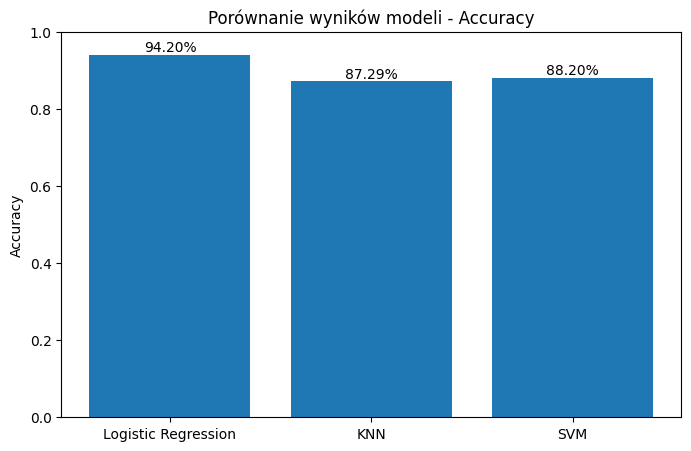

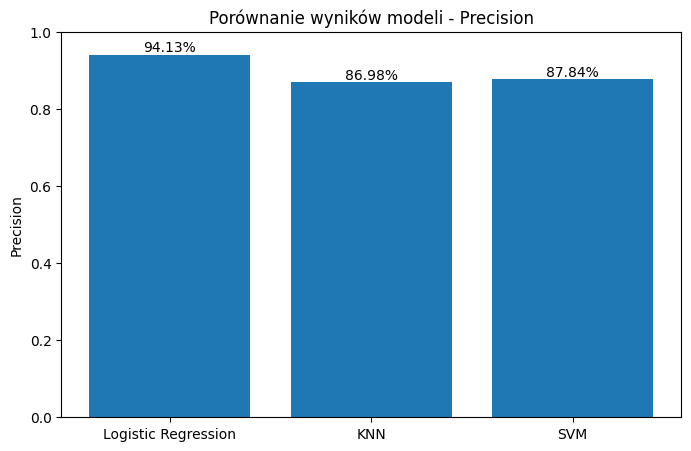

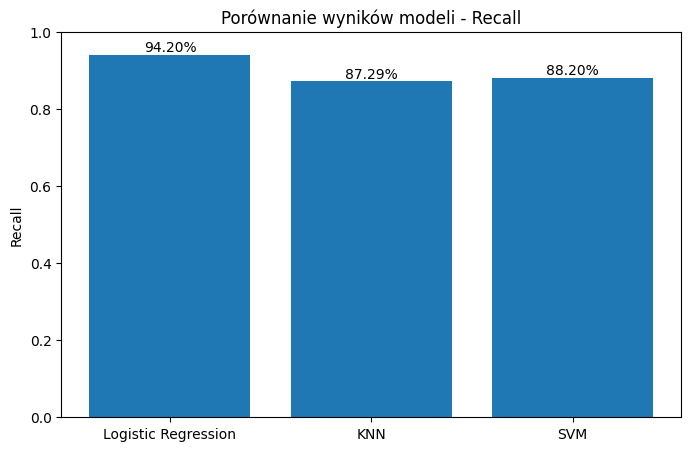

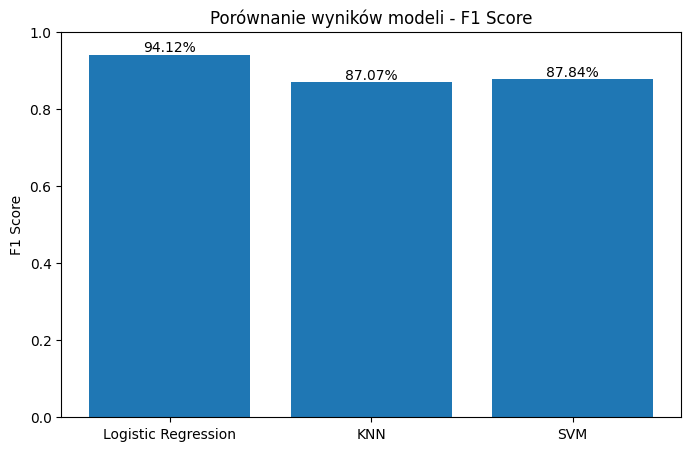

In [107]:
# Zmienne z wartościami metryk dla modeli klasyfikacyjnych
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracies, precisions, recalls, f1_scores]

for i, metric in enumerate(metrics):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(models[1:], values[i])  # Pomijamy Linear Regression jako model regresji
    plt.title(f'Porównanie wyników modeli - {metric}')
    plt.ylabel(metric)
    plt.ylim(0, 1)
    
    # Dodanie wartości nad słupkami
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval, f"{yval:.2%}", ha='center', va='bottom')
        
    plt.show()

In [113]:
# Normalizacja danych przy użyciu MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trening modeli KNN i SVM na znormalizowanych danych
knn_model_scaled = KNeighborsClassifier(n_neighbors=5)
knn_model_scaled.fit(X_train_scaled, y_train)
y_pred_knn_scaled = knn_model_scaled.predict(X_test_scaled)

svc_model_scaled = svm.SVC()
svc_model_scaled.fit(X_train_scaled, y_train)
y_pred_svc_scaled = svc_model_scaled.predict(X_test_scaled)


# Obliczenie metryk dla modeli na znormalizowanych danych
knn_accuracy_scaled, knn_precision_scaled, knn_recall_scaled, knn_f1_scaled = calculate_classification_metrics(y_test, y_pred_knn_scaled)
svc_accuracy_scaled, svc_precision_scaled, svc_recall_scaled, svc_f1_scaled = calculate_classification_metrics(y_test, y_pred_svc_scaled)

# Tworzenie DataFrame do zaprezentowania wyników
results_scaled = {
    "Model": ["KNN (Scaled)", "SVM (Scaled)"],
    "Accuracy": [knn_accuracy_scaled, svc_accuracy_scaled],
    "Precision": [knn_precision_scaled, svc_precision_scaled],
    "Recall": [knn_recall_scaled, svc_recall_scaled],
    "F1 Score": [knn_f1_scaled, svc_f1_scaled]
}
results_df = pd.DataFrame(results_scaled)

# Wyświetlenie wyników
print("Wyniki modeli KNN i SVM po normalizacji danych :")
print(results_df)

# Normalizacja poprawiła skuteczność SVM, który osiągnął wyraźnie wyższe wyniki. 

Wyniki modeli KNN i SVM po normalizacji danych :
          Model  Accuracy  Precision    Recall  F1 Score
0  KNN (Scaled)  0.835098   0.828134  0.835098  0.819560
1  SVM (Scaled)  0.927887   0.927173  0.927887  0.925957


In [114]:
# Standaryzacja danych przy użyciu StandardScaler
scaler_standard = StandardScaler()
X_train_standardized = scaler_standard.fit_transform(X_train)
X_test_standardized = scaler_standard.transform(X_test)

# Trening modeli KNN i SVM na standaryzowanych danych
knn_model_standardized = KNeighborsClassifier(n_neighbors=5)
knn_model_standardized.fit(X_train_standardized, y_train)
y_pred_knn_standardized = knn_model_standardized.predict(X_test_standardized)

svc_model_standardized = svm.SVC()
svc_model_standardized.fit(X_train_standardized, y_train)
y_pred_svc_standardized = svc_model_standardized.predict(X_test_standardized)

# Obliczenie metryk dla modeli na standaryzowanych danych
knn_accuracy_standard, knn_precision_standard, knn_recall_standard, knn_f1_standard = calculate_classification_metrics(y_test, y_pred_knn_standardized)
svc_accuracy_standard, svc_precision_standard, svc_recall_standard, svc_f1_standard = calculate_classification_metrics(y_test, y_pred_svc_standardized)

# Tworzenie DataFrame do zaprezentowania wyników standaryzacji
results_standardized = {
    "Model": ["KNN (Standardized)", "SVM (Standardized)"],
    "Accuracy": [knn_accuracy_standard, svc_accuracy_standard],
    "Precision": [knn_precision_standard, svc_precision_standard],
    "Recall": [knn_recall_standard, svc_recall_standard],
    "F1 Score": [knn_f1_standard, svc_f1_standard]
}
results_df_standard = pd.DataFrame(results_standardized)

# Wyświetlenie wyników
print("Wyniki modeli KNN i SVM po standaryzacji danych:")
print(results_df_standard)

# Standaryzacja poprawiła wyniki SVM, który osiągnął bardzo wysoką skuteczność. 

Wyniki modeli KNN i SVM po standaryzacji danych:
                Model  Accuracy  Precision    Recall  F1 Score
0  KNN (Standardized)  0.859808   0.855830  0.859808  0.849787
1  SVM (Standardized)  0.930408   0.929628  0.930408  0.928755


Porównanie wyników oryginalnych danych, po normalizacji oraz po standaryzacji.

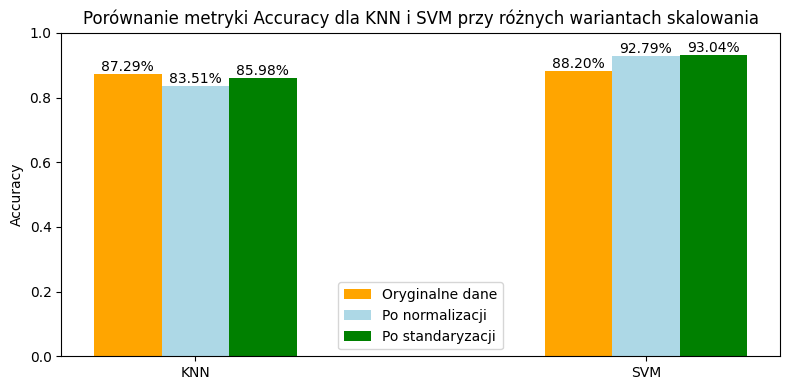

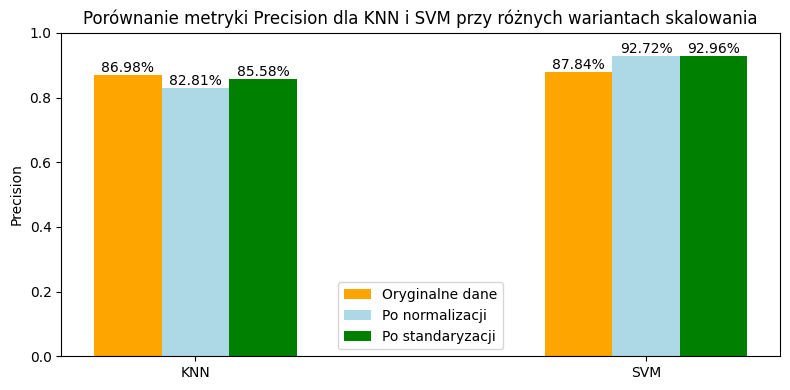

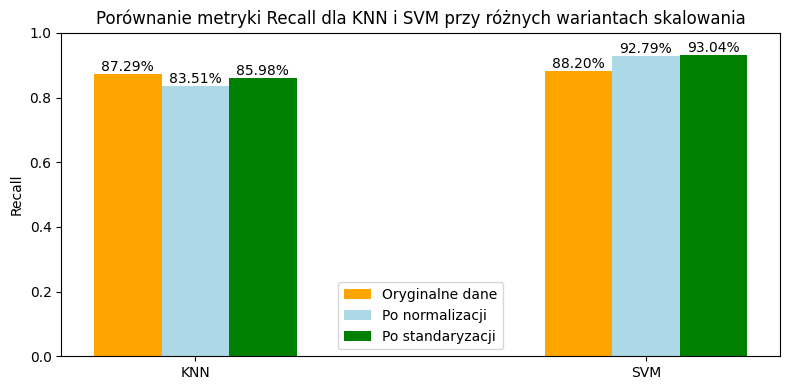

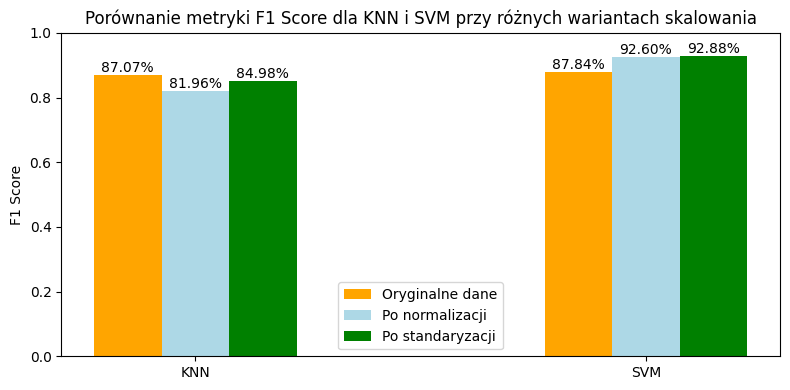

In [125]:
results_df = pd.DataFrame({
    "Model": ["KNN (No Scaling)", "SVM (No Scaling)", "KNN (Normalized)", "SVM (Normalized)", "KNN (Standardized)", "SVM (Standardized)"],
    "Accuracy": [acc_knn, acc_svc, knn_accuracy_scaled, svc_accuracy_scaled, knn_accuracy_standard, svc_accuracy_standard],
    "Precision": [prec_knn, prec_svc, knn_precision_scaled, svc_precision_scaled, knn_precision_standard, svc_precision_standard],
    "Recall": [rec_knn, rec_svc, knn_recall_scaled, svc_recall_scaled, knn_recall_standard, svc_recall_standard],
    "F1 Score": [f1_knn, f1_svc, knn_f1_scaled, svc_f1_scaled, knn_f1_standard, svc_f1_standard]
})

# Tworzenie wykresów dla każdej metryki
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x_labels = ["KNN", "SVM"]
scales = ["Oryginalne dane", "Po normalizacji", "Po standaryzacji"]

for metric in metrics:
    plt.figure(figsize=(8, 4))
    x = np.arange(len(x_labels))  # KNN, SVM
    width = 0.15  # Szerokość słupków

    # Wartości dla każdej skali
    values_no_scaling = results_df[results_df['Model'].str.contains("No Scaling")][metric].values
    values_normalized = results_df[results_df['Model'].str.contains("Normalized")][metric].values
    values_standardized = results_df[results_df['Model'].str.contains("Standardized")][metric].values

    # Wykres słupkowy
    plt.bar(x - width, values_no_scaling, width, label='Oryginalne dane', color='orange')
    plt.bar(x, values_normalized, width, label='Po normalizacji', color='lightblue')
    plt.bar(x + width, values_standardized, width, label='Po standaryzacji', color='green')

    # Dostosowanie wykresu
    plt.ylabel(metric)
    plt.title(f'Porównanie metryki {metric} dla KNN i SVM przy różnych wariantach skalowania')
    plt.xticks(x, x_labels)
    plt.ylim(0, 1)
    plt.legend()

    # Dodanie wartości nad słupkami
    for i, value in enumerate(values_no_scaling):
        plt.text(i - width, value, f"{value:.2%}", ha='center', va='bottom')
    for i, value in enumerate(values_normalized):
        plt.text(i, value, f"{value:.2%}", ha='center', va='bottom')
    for i, value in enumerate(values_standardized):
        plt.text(i + width, value, f"{value:.2%}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()